In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

In [2]:
# Cell 2: Upload file in Colab
from google.colab import files
uploaded = files.upload()   # choose SinterTrialData.csv when prompted

Saving SinterTrialData  - SinterTrialData .csv to SinterTrialData  - SinterTrialData  (1).csv


In [4]:
# Cell 3: Load data

import os

print("Uploaded files:")
print(os.listdir())

# Use the actual uploaded filename
filename = "SinterTrialData  - SinterTrialData .csv"

raw = pd.read_csv(filename, header=None, skiprows=2)

cols = ["Date", "Fe", "CaO", "SiO2", "P", "MgO", "Al2O3",
        "TiO2", "K2O", "S", "Basicity", "TI", "RDI"]

raw.columns = cols

df = raw.copy()

df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")
df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)
df.head()

Uploaded files:
['.config', 'SinterTrialData  - SinterTrialData .csv', 'SinterTrialData  - SinterTrialData  (1).csv', 'sample_data']
(50, 13)


,Date,Fe,CaO,SiO2,P,MgO,Al2O3,TiO2,K2O,S,Basicity,TI,RDI
0,2015-04-01,54.39,11.51,5.76,0.099,2.48,2.19,0.20,0.052,0.008,2.43,70.2,24.85
1,2015-04-02,54.86,11.67,5.74,0.061,2.16,1.79,0.14,0.067,0.003,2.41,73.2,23.30
2,2015-04-03,53.84,12.01,5.87,0.113,2.32,2.52,0.18,0.049,0.017,2.44,69.5,26.21
3,2015-04-04,53.35,12.35,5.96,0.110,1.69,3.44,0.17,0.050,0.015,2.36,66.3,36.58
4,2015-04-05,55.20,11.57,5.55,0.070,1.01,2.63,0.15,0.150,0.017,2.27,69.6,26.34


In [5]:
# Cell 4: Data health check
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDescriptive statistics:\n")
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      50 non-null     datetime64[ns]
 1   Fe        50 non-null     float64       
 2   CaO       50 non-null     float64       
 3   SiO2      50 non-null     float64       
 4   P         50 non-null     float64       
 5   MgO       50 non-null     float64       
 6   Al2O3     50 non-null     float64       
 7   TiO2      50 non-null     float64       
 8   K2O       50 non-null     float64       
 9   S         50 non-null     float64       
 10  Basicity  50 non-null     float64       
 11  TI        50 non-null     float64       
 12  RDI       50 non-null     float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 5.2 KB
None

Missing values:
 Date        0
Fe          0
CaO         0
SiO2        0
P           0
MgO         0
Al2O3       0
TiO2        0
K2O         

,count,mean,min,25%,50%,75%,max,std
Date,50,2015-04-25 12:00:00,2015-04-01 00:00:00,2015-04-13 06:00:00,2015-04-25 12:00:00,2015-05-07 18:00:00,2015-05-20 00:00:00,NaN
Fe,50.0,54.4644,52.19,53.945,54.555,55.025,56.58,0.886348
CaO,50.0,12.0836,9.98,11.6175,12.15,12.41,13.92,0.735268
SiO2,50.0,5.4618,4.52,5.3425,5.49,5.6425,6.06,0.322298
P,50.0,0.0948,0.061,0.0855,0.092,0.1085,0.124,0.016269
MgO,50.0,1.5462,0.91,1.2625,1.525,1.7925,2.49,0.39111
Al2O3,50.0,2.7602,1.61,2.285,2.875,3.24,3.55,0.561748
TiO2,50.0,0.1636,0.14,0.15,0.16,0.17,0.2,0.016132
K2O,50.0,0.06928,0.04,0.05125,0.064,0.077,0.15,0.025044
S,50.0,0.01432,0.001,0.01,0.015,0.01975,0.027,0.006607


In [6]:
# Cell 5: Outlier detection for target sinter properties
targets = ["Basicity", "TI", "RDI"]

def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return series[(series < lower) | (series > upper)]

for t in targets:
    out = iqr_outliers(df[t])
    print(f"{t}: {len(out)} outlier(s) -> {list(out.values)}")

Basicity: 0 outlier(s) -> []
TI: 0 outlier(s) -> []
RDI: 0 outlier(s) -> []


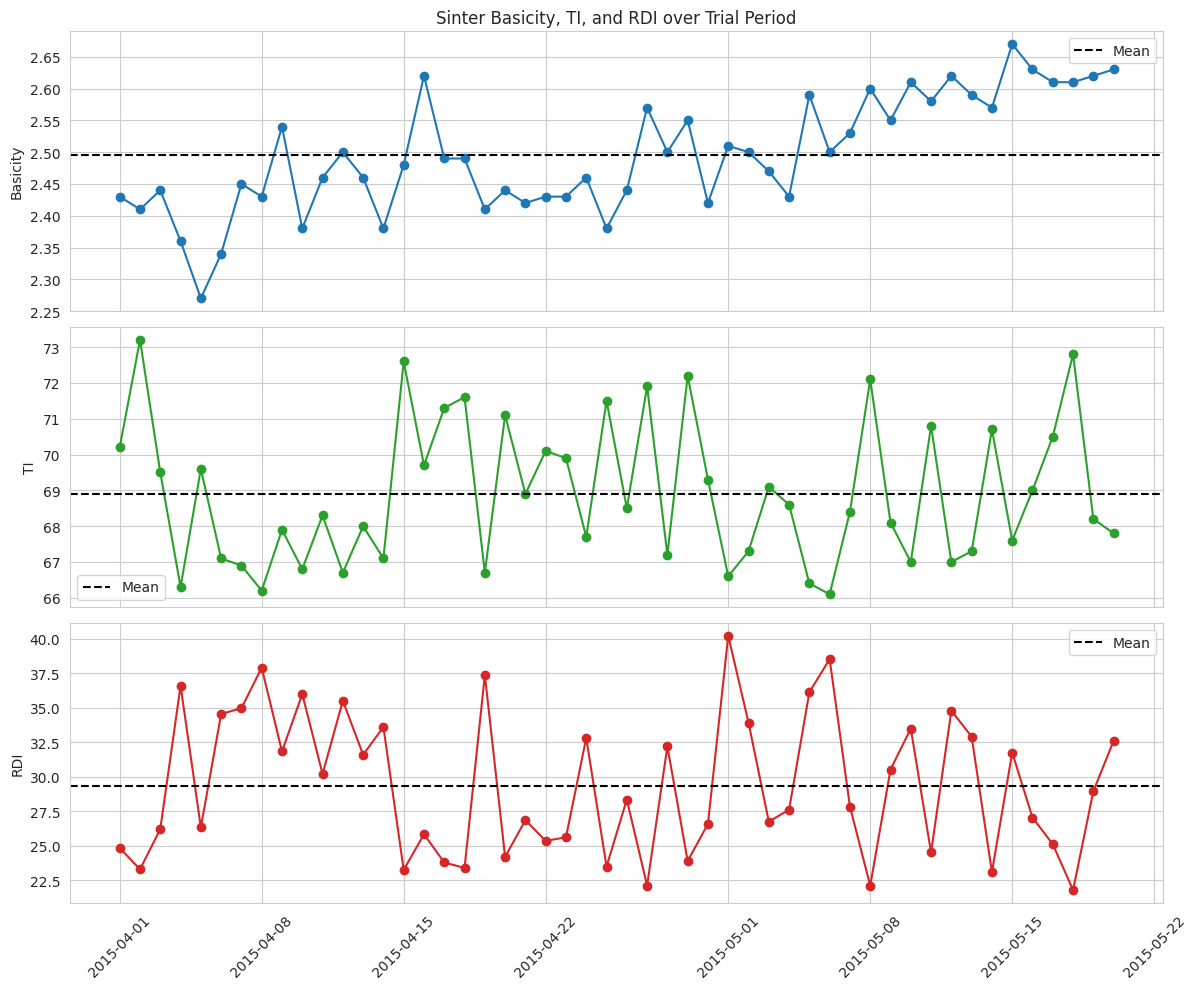

In [7]:
# Cell 6: Trend of sinter properties over trial period
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, col, color in zip(axes, targets, ["tab:blue", "tab:green", "tab:red"]):
    ax.plot(df["Date"], df[col], marker="o", color=color)
    ax.axhline(df[col].mean(), color="black", linestyle="--", label="Mean")
    ax.set_ylabel(col)
    ax.legend()

axes[0].set_title("Sinter Basicity, TI, and RDI over Trial Period")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

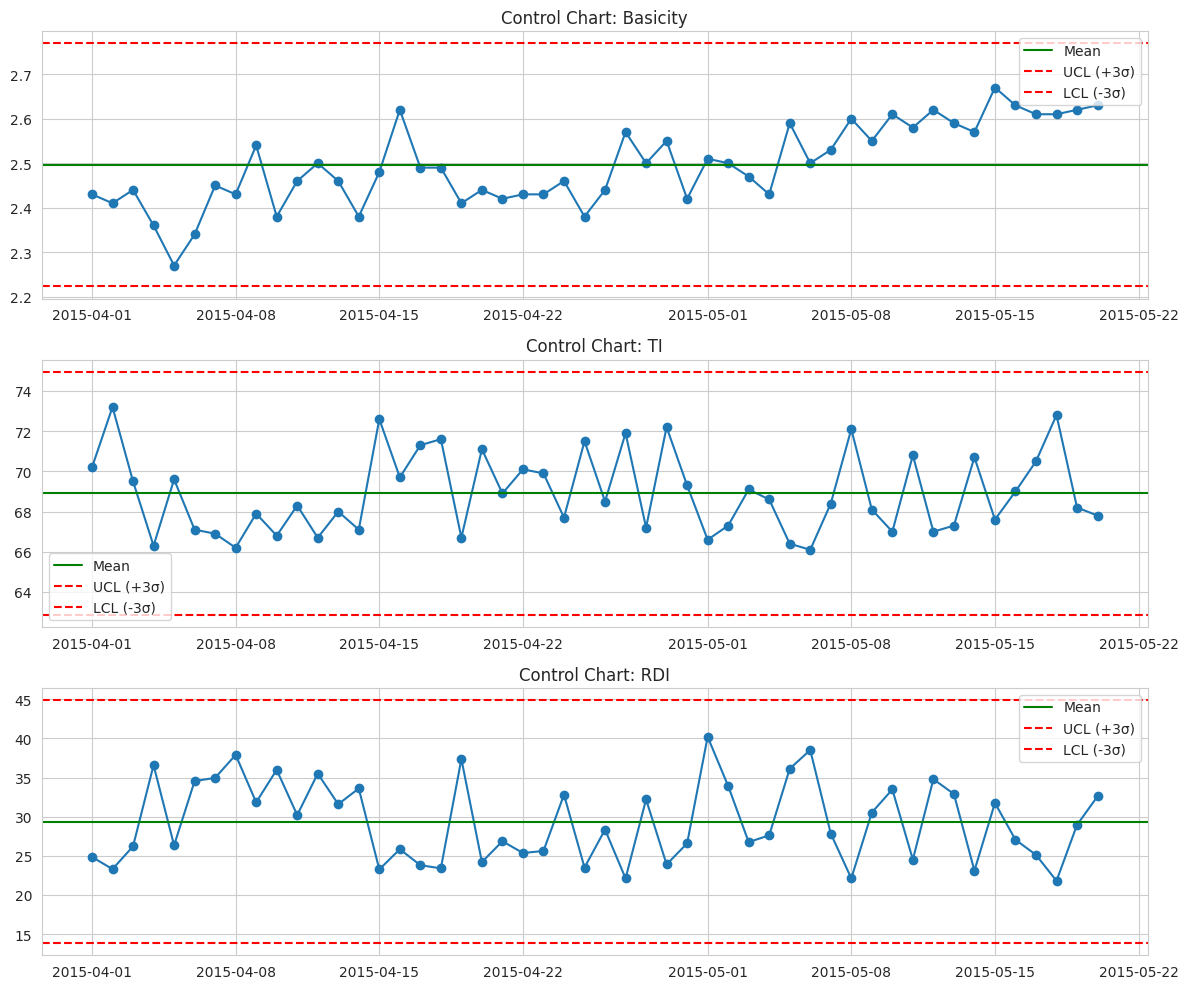

Coefficient of Variation (%) - lower = more uniform:

Basicity: CV = 3.65%
TI: CV = 2.92%
RDI: CV = 17.61%


In [8]:
# Cell 7: Control charts to quantify "irregularity"
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, col in zip(axes, targets):
    mean, std = df[col].mean(), df[col].std()
    ucl, lcl = mean + 3*std, mean - 3*std
    ax.plot(df["Date"], df[col], marker="o")
    ax.axhline(mean, color="green", label="Mean")
    ax.axhline(ucl, color="red", linestyle="--", label="UCL (+3σ)")
    ax.axhline(lcl, color="red", linestyle="--", label="LCL (-3σ)")
    ax.set_title(f"Control Chart: {col}")
    ax.legend()

plt.tight_layout()
plt.show()

# Coefficient of Variation (CV%) -> quantifies "how uniform"
print("Coefficient of Variation (%) - lower = more uniform:\n")
for col in targets:
    cv = (df[col].std() / df[col].mean()) * 100
    print(f"{col}: CV = {cv:.2f}%")

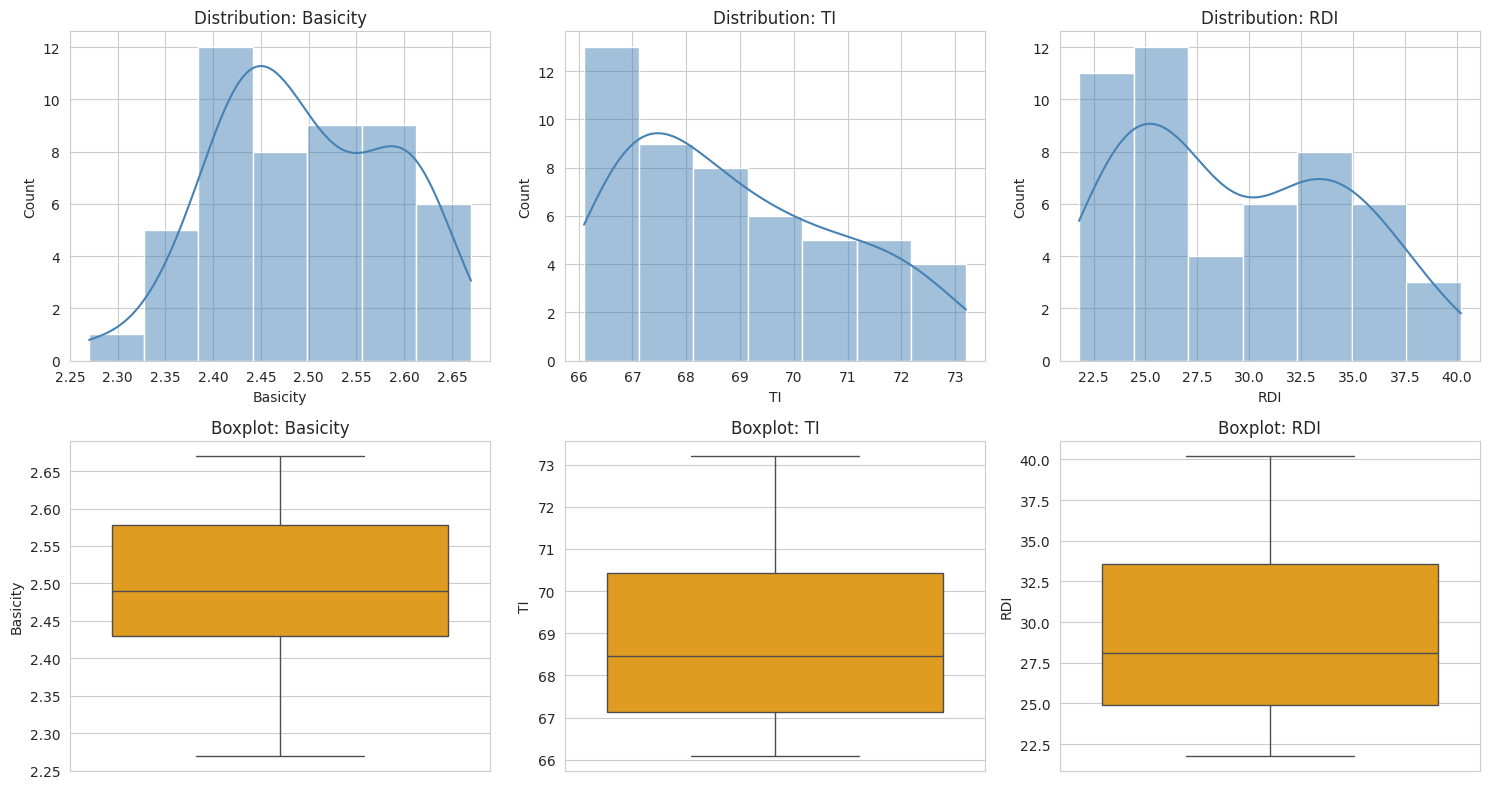

In [9]:
# Cell 8: Distribution shape of each target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution: {col}")
    sns.boxplot(y=df[col], ax=axes[1, i], color="orange")
    axes[1, i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

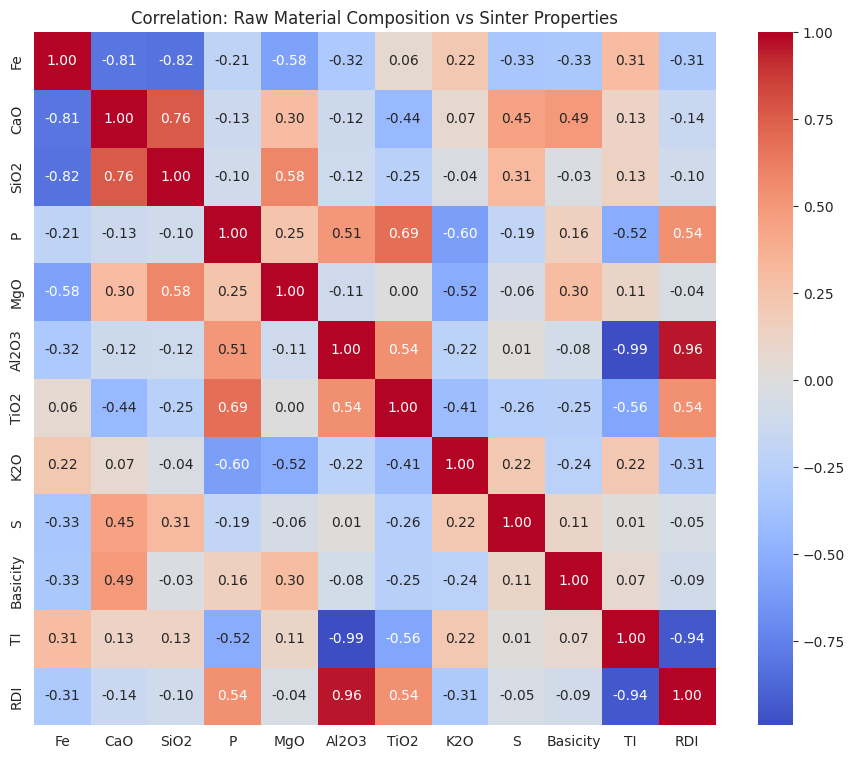

Correlation of raw-material composition with sinter properties:

       Basicity        TI       RDI
Fe    -0.326214  0.307564 -0.308897
CaO    0.487793  0.127990 -0.144018
SiO2  -0.026677  0.132962 -0.103723
P      0.160170 -0.522789  0.538279
MgO    0.298585  0.108176 -0.043027
Al2O3 -0.084338 -0.990659  0.958035
TiO2  -0.252725 -0.559284  0.539988
K2O   -0.235453  0.219650 -0.313855
S      0.108414  0.007932 -0.050901


In [10]:
# Cell 9: Correlation matrix
features = ["Fe", "CaO", "SiO2", "P", "MgO", "Al2O3", "TiO2", "K2O", "S"]
corr = df[features + targets].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Raw Material Composition vs Sinter Properties")
plt.show()

# Isolate correlations of features with each target
print("Correlation of raw-material composition with sinter properties:\n")
print(corr.loc[features, targets])

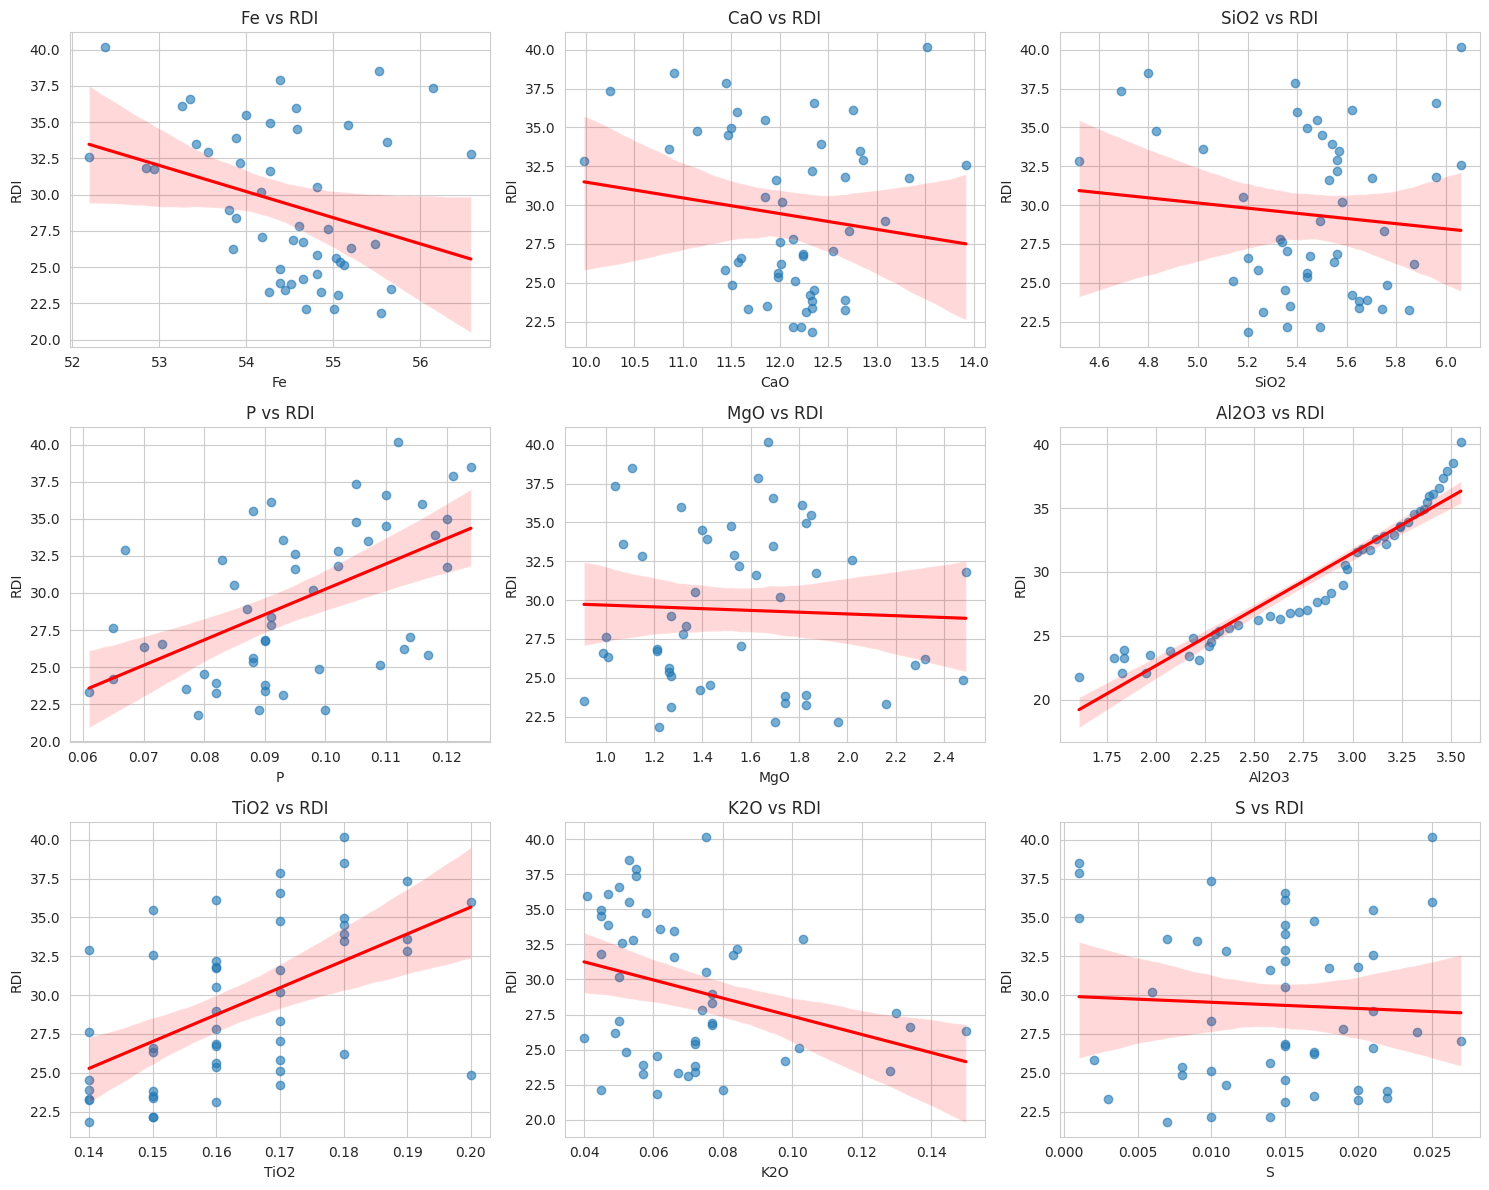

In [11]:
# Cell 10: Pairwise relationships
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.regplot(x=df[feat], y=df["RDI"], ax=axes[i],
                scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
    axes[i].set_title(f"{feat} vs RDI")

plt.tight_layout()
plt.show()

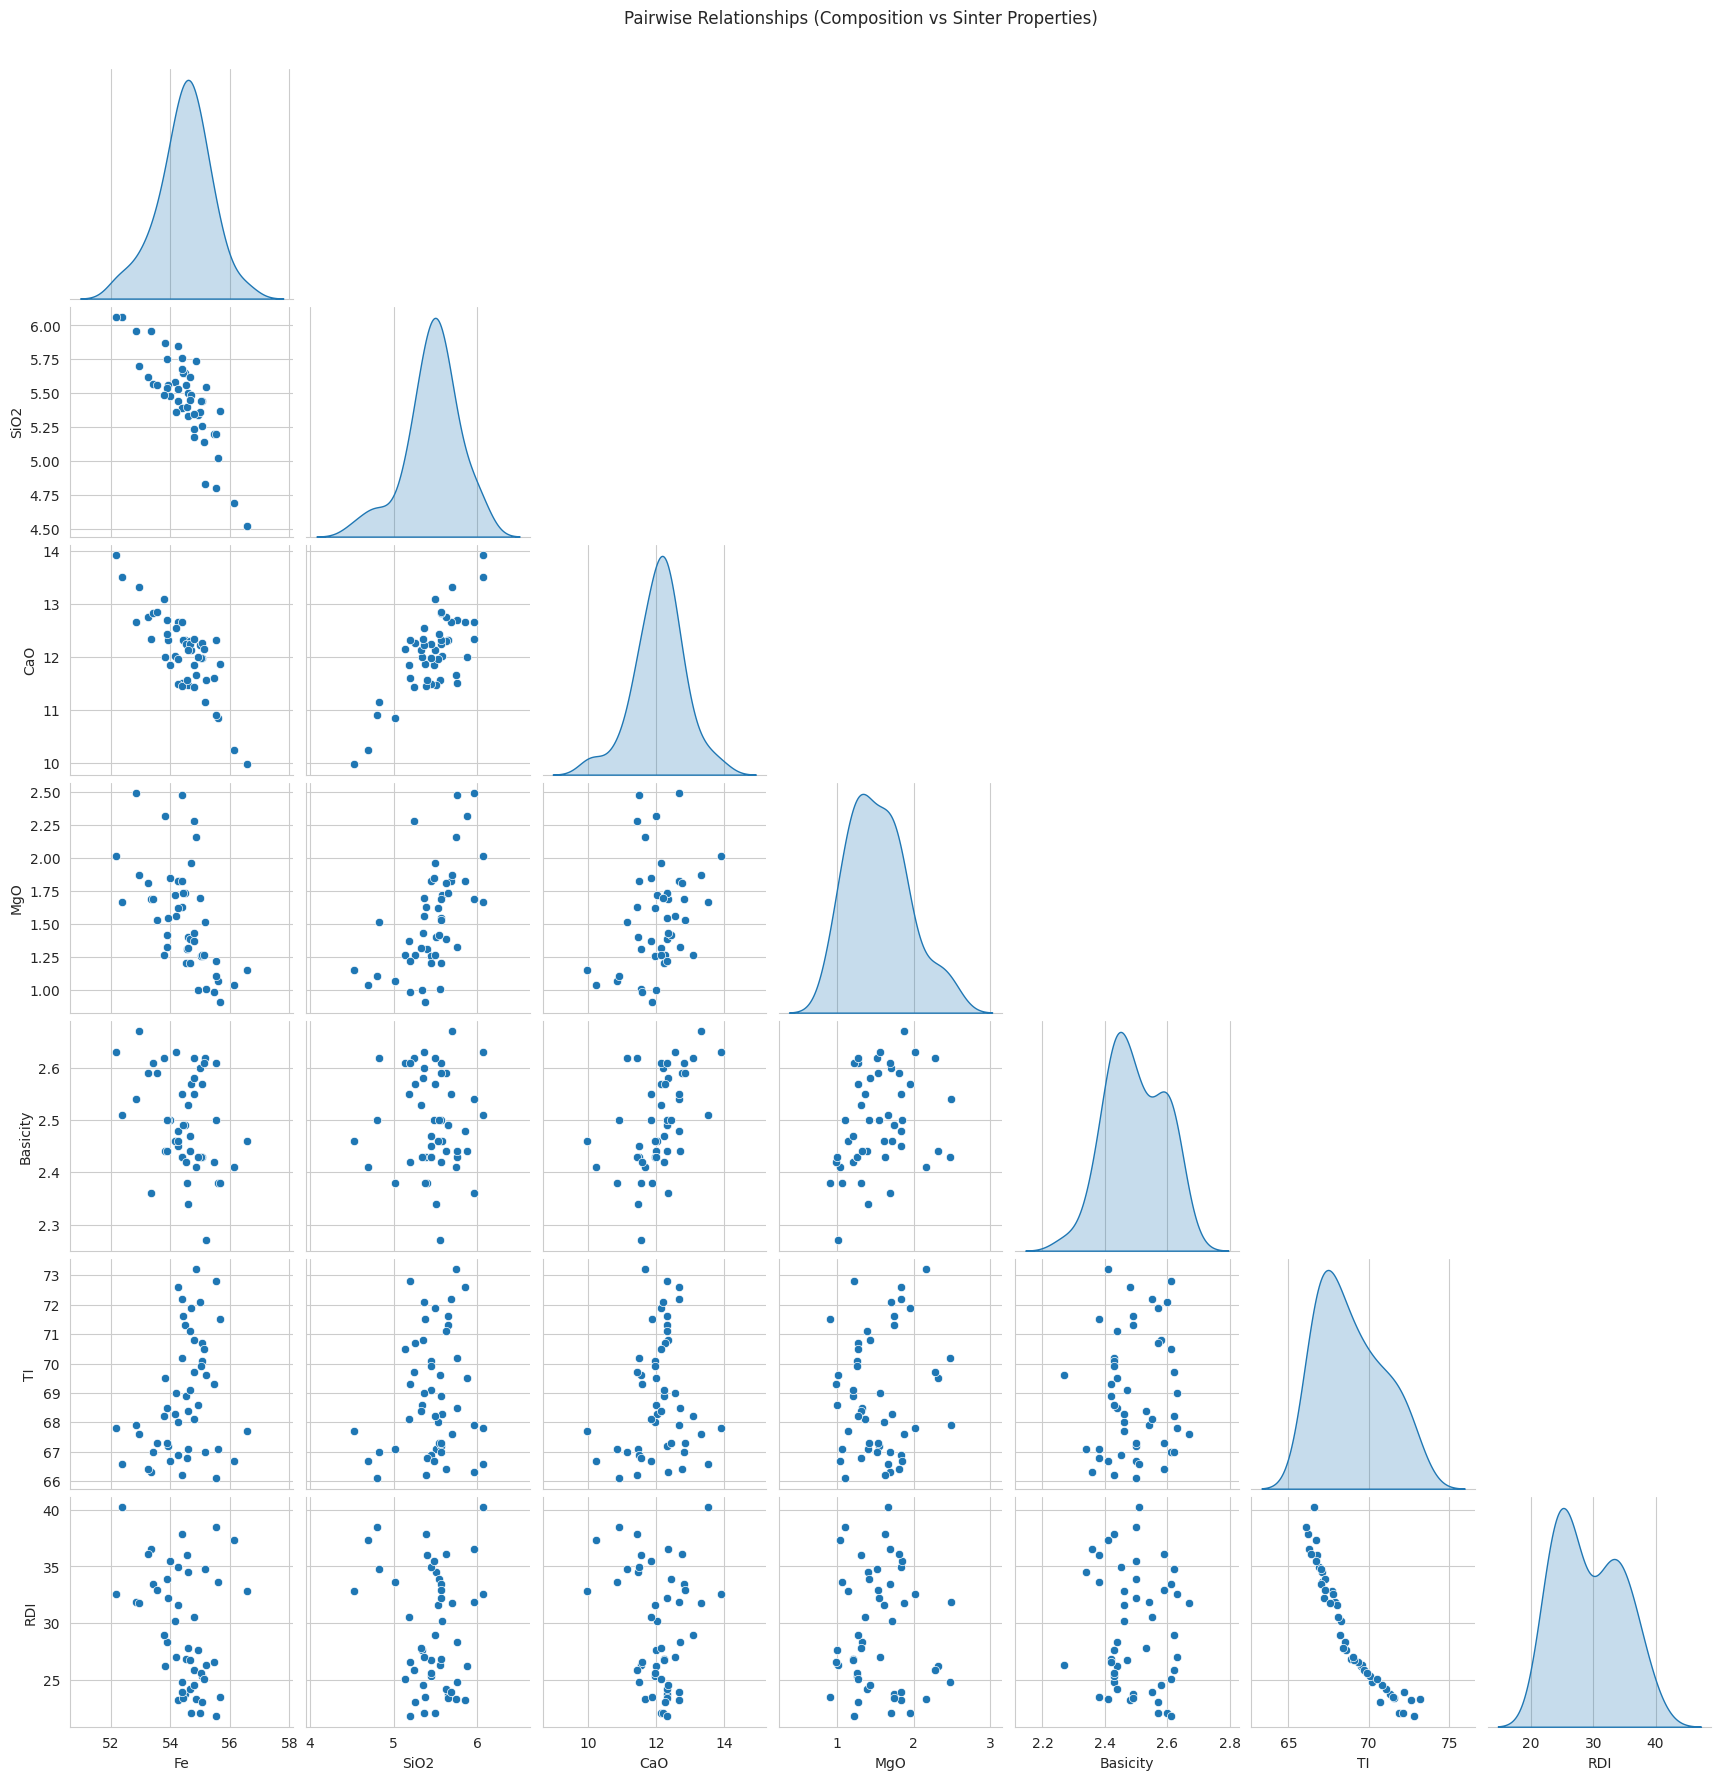

In [12]:
# Cell 11: Pairplot (subset of most relevant variables)
subset_cols = ["Fe", "SiO2", "CaO", "MgO", "Basicity", "TI", "RDI"]
sns.pairplot(df[subset_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships (Composition vs Sinter Properties)", y=1.02)
plt.show()

In [13]:
# Cell 12: Feature scaling
scaler = StandardScaler()
X = df[features]
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# Min-Max scaled version (for interpretability/plots, 0-1 range)
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X), columns=features)

X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Fe,50.0,-1.362466e-14,1.010153,-2.592087,-0.591949,0.103255,0.638904,2.411106
CaO,50.0,-7.105427e-16,1.010153,-2.890043,-0.640354,0.091224,0.448427,2.522949
SiO2,50.0,-6.084022e-16,1.010153,-2.951803,-0.373912,0.088385,0.566353,1.874887
P,50.0,-5.920611e-16,1.010153,-2.098610,-0.577428,-0.173849,0.850620,1.813000
MgO,50.0,-4.440892e-17,1.010153,-1.643168,-0.732736,-0.054755,0.636140,2.437632
Al2O3,50.0,4.063416e-16,1.010153,-2.068324,-0.854519,0.206437,0.862791,1.420242
TiO2,50.0,5.351275e-16,1.010153,-1.477773,-0.851598,-0.225423,0.400752,2.279278
K2O,50.0,-3.486100e-16,1.010153,-1.181028,-0.727252,-0.212972,0.311391,3.255893
S,50.0,-1.953993e-16,1.010153,-2.036554,-0.660504,0.103968,0.830217,1.938702


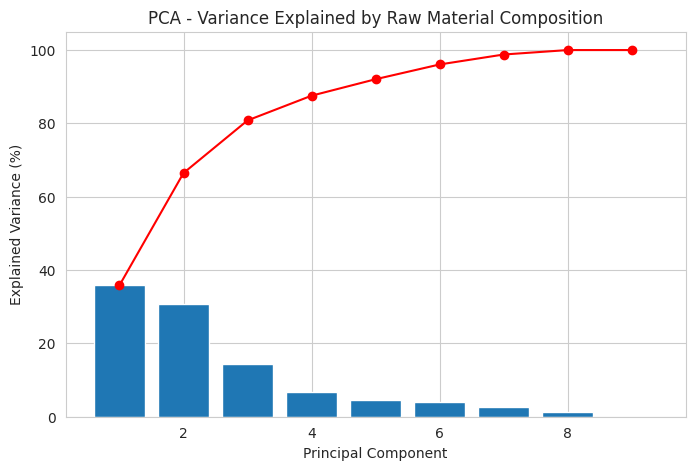

,PC1,PC2
Fe,-0.485990,-0.243630
CaO,0.507010,-0.047101
SiO2,0.509283,0.055322
P,-0.082340,0.526077
MgO,0.318901,0.284930
Al2O3,-0.076018,0.374112
TiO2,-0.242981,0.447180
K2O,-0.012248,-0.465916
S,0.271919,-0.142887


In [14]:
# Cell 13: PCA on scaled composition data
pca = PCA()
pcs = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained)+1), explained*100)
plt.plot(range(1, len(explained)+1), np.cumsum(explained)*100, "ro-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA - Variance Explained by Raw Material Composition")
plt.show()

# Loadings of PC1 & PC2 -> which raw materials drive the biggest variation
loadings = pd.DataFrame(pca.components_[:2].T, index=features, columns=["PC1", "PC2"])
loadings

/tmp/ipykernel_977/2451894341.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.arrow(0, 0, loadings.PC1[i]*3, loadings.PC2[i]*3, color="red", alpha=0.6)
/tmp/ipykernel_977/2451894341.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(loadings.PC1[i]*3.2, loadings.PC2[i]*3.2, feat, color="red")


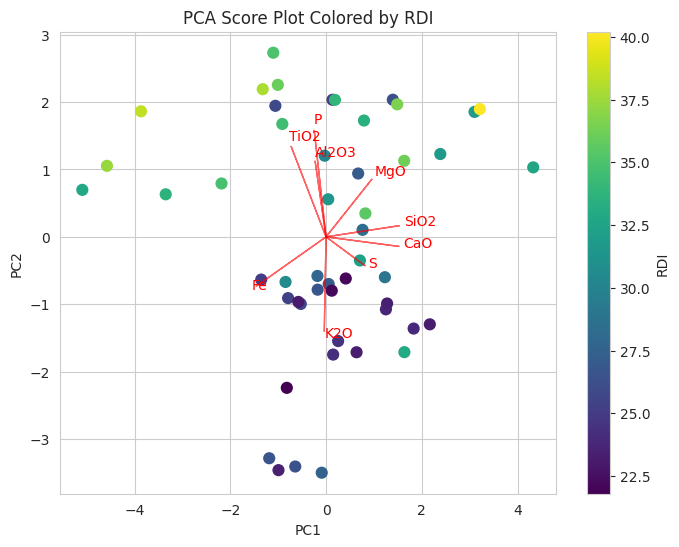

In [15]:
# Cell 14: PCA biplot (PC1 vs PC2) colored by RDI
plt.figure(figsize=(8,6))
sc = plt.scatter(pcs[:,0], pcs[:,1], c=df["RDI"], cmap="viridis", s=60)
plt.colorbar(sc, label="RDI")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot Colored by RDI")

for i, feat in enumerate(features):
    plt.arrow(0, 0, loadings.PC1[i]*3, loadings.PC2[i]*3, color="red", alpha=0.6)
    plt.text(loadings.PC1[i]*3.2, loadings.PC2[i]*3.2, feat, color="red")

plt.show()

In [16]:
# Cell 15: Feature importance modeling per target
importance_results = {}

for target in targets:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, df[target], test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"--- Target: {target} | R2 = {r2:.2f} | RMSE = {rmse:.2f} ---")

    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    importance_results[target] = importances
    print(importances, "\n")

--- Target: Basicity | R2 = 0.39 | RMSE = 0.06 ---
CaO      0.348388
SiO2     0.161879
MgO      0.132047
K2O      0.105587
Fe       0.076820
Al2O3    0.071282
P        0.039531
S        0.034203
TiO2     0.030263
dtype: float64 

--- Target: TI | R2 = 0.96 | RMSE = 0.38 ---
Al2O3    0.972212
CaO      0.005175
S        0.004480
K2O      0.004201
P        0.003967
TiO2     0.003753
SiO2     0.002400
MgO      0.002162
Fe       0.001651
dtype: float64 

--- Target: RDI | R2 = 0.92 | RMSE = 1.46 ---
Al2O3    0.976064
SiO2     0.004327
CaO      0.004256
S        0.003994
P        0.002932
K2O      0.002787
Fe       0.002574
MgO      0.001949
TiO2     0.001118
dtype: float64 



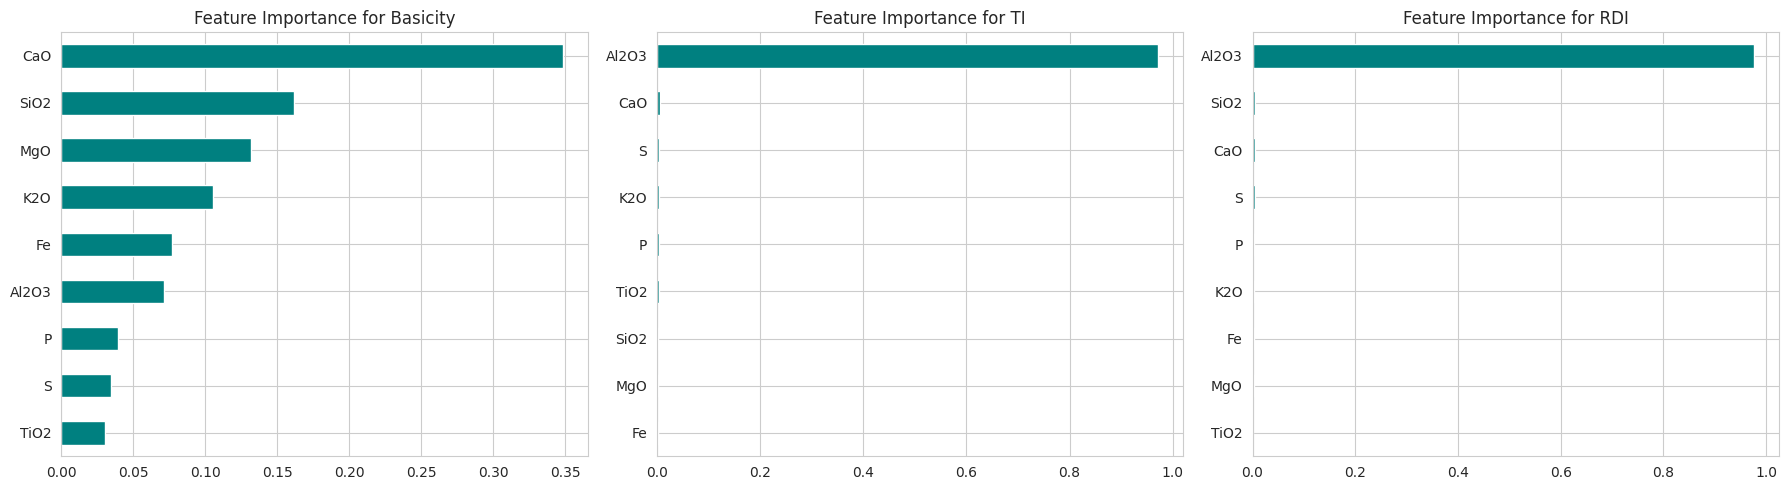

In [17]:
# Cell 16: Plot feature importances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):
    importance_results[target].plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature Importance for {target}")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

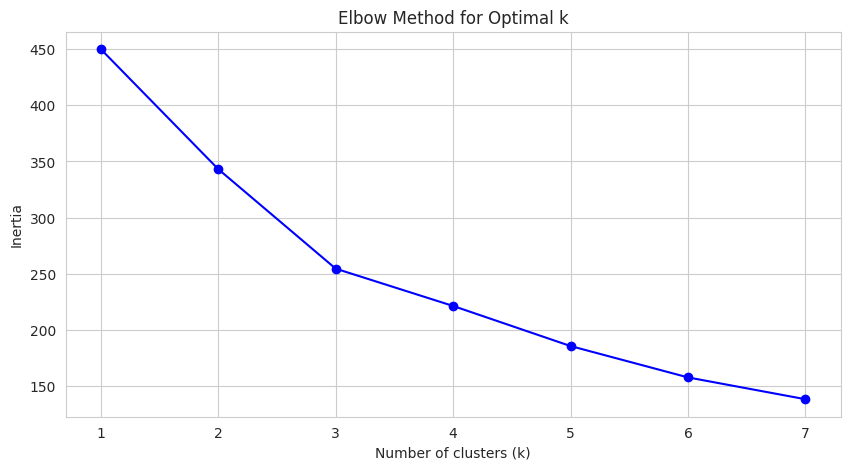

In [18]:
# Cell 17: KMeans clustering (find natural groupings in raw material batches)
inertia = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, "bo-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

                Fe        CaO      SiO2         P       MgO     Al2O3  \
Cluster                                                                 
0        54.820000  12.164348  5.452609  0.082783  1.417826  2.317391   
1        55.165000  11.056000  5.083000  0.111300  1.434000  3.267000   
2        53.571176  12.578824  5.697059  0.101353  1.785882  3.061176   

             TiO2       K2O         S  Basicity         TI        RDI  
Cluster                                                                
0        0.151739  0.084087  0.015174  2.492174  70.504348  25.240870  
1        0.182000  0.050800  0.009000  2.459000  67.130000  34.627000  
2        0.168824  0.060118  0.016294  2.522941  67.794118  31.845882  


/tmp/ipykernel_977/2080461555.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=col, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_977/2080461555.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=col, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_977/2080461555.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=col, data=df, ax=ax, palette="Set2")


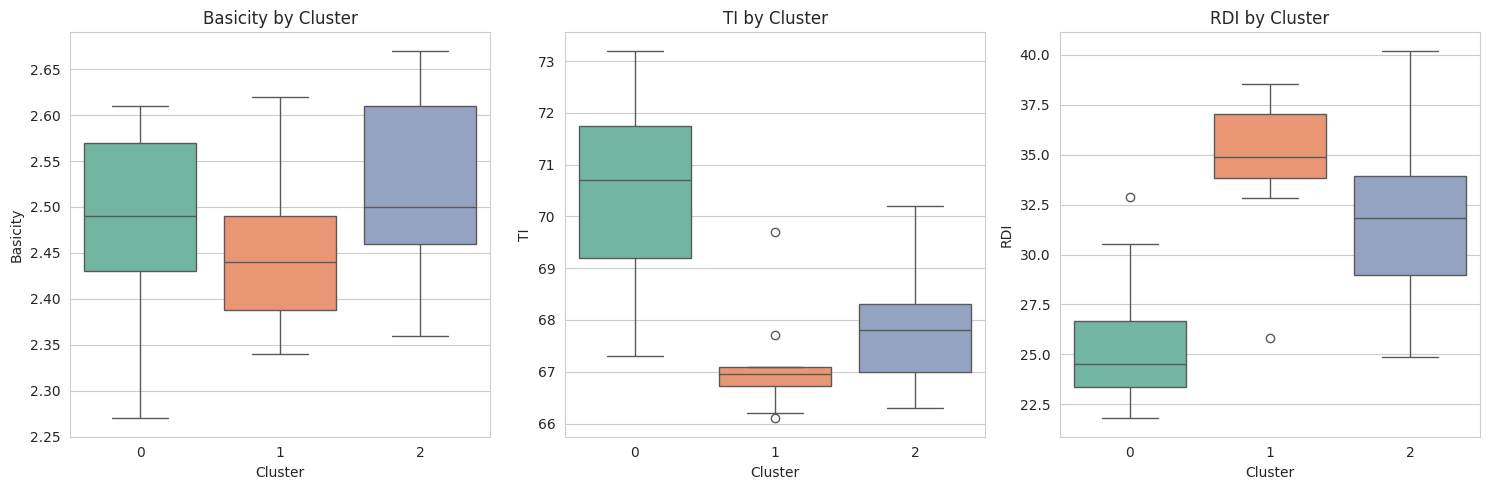

In [19]:
# Cell 18: Fit final KMeans (choose k based on elbow, e.g., k=3) and inspect clusters
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X_scaled)

cluster_summary = df.groupby("Cluster")[features + targets].mean()
print(cluster_summary)

# Visualize cluster-wise RDI/TI/Basicity spread
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, targets):
    sns.boxplot(x="Cluster", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} by Cluster")
plt.tight_layout()
plt.show()

In [20]:
# Cell 19: One-way ANOVA across clusters for each target
for col in targets:
    groups = [df[df["Cluster"] == c][col] for c in df["Cluster"].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "Significant" if p_val < 0.05 else "Not significant"
    print(f"{col}: F={f_stat:.2f}, p={p_val:.4f} -> {sig} difference between clusters")

Basicity: F=1.63, p=0.2062 -> Not significant difference between clusters
TI: F=29.91, p=0.0000 -> Significant difference between clusters
RDI: F=33.76, p=0.0000 -> Significant difference between clusters


In [21]:
# Cell 20: Correlation p-values (statistical significance)
print("Correlation & p-value between key raw materials and RDI:\n")
for feat in features:
    r, p = stats.pearsonr(df[feat], df["RDI"])
    flag = "**Significant**" if p < 0.05 else "Not significant"
    print(f"{feat:8s} vs RDI: r={r:.3f}, p={p:.4f} -> {flag}")

Correlation & p-value between key raw materials and RDI:

Fe       vs RDI: r=-0.309, p=0.0291 -> **Significant**
CaO      vs RDI: r=-0.144, p=0.3184 -> Not significant
SiO2     vs RDI: r=-0.104, p=0.4735 -> Not significant
P        vs RDI: r=0.538, p=0.0001 -> **Significant**
MgO      vs RDI: r=-0.043, p=0.7667 -> Not significant
Al2O3    vs RDI: r=0.958, p=0.0000 -> **Significant**
TiO2     vs RDI: r=0.540, p=0.0001 -> **Significant**
K2O      vs RDI: r=-0.314, p=0.0264 -> **Significant**
S        vs RDI: r=-0.051, p=0.7256 -> Not significant


In [22]:
# Cell 21: Consolidated summary table
summary = pd.DataFrame({
    "Mean": df[targets].mean(),
    "Std Dev": df[targets].std(),
    "CV (%)": (df[targets].std() / df[targets].mean()) * 100,
    "Min": df[targets].min(),
    "Max": df[targets].max()
})
summary

,Mean,Std Dev,CV (%),Min,Max
Basicity,2.4960,0.091003,3.645973,2.27,2.67
TI,68.9080,2.014118,2.922908,66.10,73.20
RDI,29.3638,5.171686,17.612456,21.80,40.20
